# GPU Hitfinder — 500-Frame ePix10k Scan

Runs `GPUHitfinder` (pyFAI OCL_PeakFinder) on the first 500 frames of the ePix10k
Resonet CXI file and provides:

1. **Scan loop** — peak counts, labels, timing for all frames in one pass
2. **Summary stats** — sensitivity, false-positive rate, confusion matrix
3. **Distribution plots** — peak count histogram for hits vs non-hits
4. **Interactive frame viewer** — play/back/forward through all frames with peak overlay

**File:** `/data/bioxfel/user/gihan/Resonet/production/epix10k_20k/compressed0.cxi`  
**Pipeline order:** assemble → find_peaks (raw frame, pre-GCN/LCN)

In [56]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /data/bioxfel/user/gihan/Hit_finder


In [57]:
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

import hdf5plugin  # must come before h5py
import h5py

## Global configuration

Edit this cell to change GPU parameters or scan size for the entire notebook.

In [58]:
# ── GPU hitfinder parameters ──────────────────────────────────────────────────
MIN_ADU         = 200.0   # absolute intensity floor (ADU)
GPU_CUTOFF_PEAK = 3.0     # azimuthal σ SNR threshold
MIN_PIX         = 7       # min connected pixels per peak
MIN_RES         = 80       # min distance from frame centre (px); 0 = disabled
MAX_RES         = 0       # max distance from frame centre (px); 0 = disabled

# ── Scan parameters ───────────────────────────────────────────────────────────
N_FRAMES        = 500     # number of frames to process
HIT_THRESHOLD   = 15      # hitfinder calls a frame a hit if n_peaks > this

EPIX_CXI_PATH  = "/data/bioxfel/user/gihan/Resonet/production/epix10k_20k/compressed0.cxi"
GPU_PF8_SCRIPT = os.path.join(PROJECT_ROOT, "src", "hitfinders", "gpu_pf8.py")

print(f"N_FRAMES={N_FRAMES}  HIT_THRESHOLD>{HIT_THRESHOLD}  "
      f"MIN_ADU={MIN_ADU}  GPU_CUTOFF_PEAK={GPU_CUTOFF_PEAK}  "
      f"MIN_PIX={MIN_PIX}  MIN_RES={MIN_RES}  MAX_RES={MAX_RES}")

N_FRAMES=500  HIT_THRESHOLD>15  MIN_ADU=200.0  GPU_CUTOFF_PEAK=3.0  MIN_PIX=7  MIN_RES=80  MAX_RES=0


## 1. Load geometry and initialise GPU hitfinder

In [59]:
from src.preprocessing.geometry import get_geometry
from src.preprocessing.pipeline import assemble_only
from src.hitfinders.gpu import GPUHitfinder
from reborn.detector import PADAssembler

with h5py.File(EPIX_CXI_PATH, "r") as f:
    dist       = float(f["entry_1/instrument_1/detector_1/distance"][()])
    wavelength = float(f["entry_1/instrument_1/source_1/wavelength"][()])
    pixel_size = float(f["entry_1/instrument_1/detector_1/x_pixel_size"][()])
    n_total    = f["entry_1/data_1/data"].shape[0]

pads      = get_geometry("ePix10k 2.2M")
assembler = PADAssembler(pad_geometry=pads)

gpu_hf = GPUHitfinder(script_path=GPU_PF8_SCRIPT, device="cuda")
gpu_hf.set_geometry(dist=dist, wavelength=wavelength, pixel_size=pixel_size)
gpu_hf.set_params(
    MIN_INTENSITY=MIN_ADU,
    CONNECTED=MIN_PIX,
    MIN_RES=MIN_RES,
    MAX_RES=MAX_RES,
    CUTOFF_PEAK=GPU_CUTOFF_PEAK,
)

# Warmup — triggers OCL kernel compilation so it doesn't skew frame-1 timing.
with h5py.File(EPIX_CXI_PATH, "r") as f:
    _raw0 = f["entry_1/data_1/data"][0].astype(np.float32)
_asm0 = assemble_only(_raw0, pads, "ePix10k 2.2M", assembler=assembler)
_ = gpu_hf.find_peaks(_asm0)

N = min(N_FRAMES, n_total)
print(f"CXI total frames : {n_total}  →  scanning {N}")
print(f"Assembled shape  : {_asm0.shape}")
print(f"Dist={dist} m  λ={wavelength:.3e} m  px={pixel_size:.2e} m")
print("GPU hitfinder warmed up.")

  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

CXI total frames : 4000  →  scanning 500
Assembled shape  : (1667, 1667)
Dist=0.096 m  λ=1.305e-10 m  px=1.00e-04 m
GPU hitfinder warmed up.


## 2. Scan all frames

Single pass: assemble → find_peaks → store results.  
Peak arrays are stored so the interactive viewer does not need to re-run the hitfinder.

In [60]:
labels      = np.zeros(N, dtype=np.float32)
n_peaks_arr = np.zeros(N, dtype=np.int32)
time_hf_ms  = np.zeros(N, dtype=np.float32)
time_asm_ms = np.zeros(N, dtype=np.float32)
all_peaks   = [None] * N   # store peak arrays for interactive viewer

with h5py.File(EPIX_CXI_PATH, "r") as f:
    labels[:] = f["entry_1/labels/hit"][:N].astype(np.float32)

print(f"Scanning {N} frames ...")
t_scan_start = time.perf_counter()

for i in range(N):
    with h5py.File(EPIX_CXI_PATH, "r") as f:
        raw = f["entry_1/data_1/data"][i].astype(np.float32)

    t0 = time.perf_counter()
    asm = assemble_only(raw, pads, "ePix10k 2.2M", assembler=assembler)
    time_asm_ms[i] = (time.perf_counter() - t0) * 1e3

    t0 = time.perf_counter()
    peaks = gpu_hf.find_peaks(asm)
    time_hf_ms[i] = (time.perf_counter() - t0) * 1e3

    n_peaks_arr[i] = len(peaks)
    all_peaks[i]   = peaks

    if (i + 1) % 100 == 0:
        print(f"  {i+1:4d}/{N}  elapsed {time.perf_counter()-t_scan_start:.1f}s  "
              f"n_peaks={len(peaks)}  label={int(labels[i])}")

total_s = time.perf_counter() - t_scan_start
print(f"\nDone. {total_s:.1f} s total  ({total_s/N*1e3:.1f} ms/frame avg)")

Scanning 500 frames ...


/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/pyFAI/opencl/peak_finder.py:453: RepeatedKernelRetrieval: Kernel 'memset_int' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  memset = self.program.memset_int(self.queue, (1,), (1,), self.cl_mem["counter"], numpy.int32(0), numpy.int32(1))
/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/pyFAI/opencl/peak_finder.py:492: RepeatedKernelRetrieval: Kernel 'peakfinder' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  peak_search = self.program.peakfinder(self.queue, wdim_data, (wg0, wg1), *list(kw_proj.values()))


   100/500  elapsed 27.9s  n_peaks=0  label=0
   200/500  elapsed 56.2s  n_peaks=0  label=0
   300/500  elapsed 84.6s  n_peaks=0  label=0
   400/500  elapsed 113.1s  n_peaks=21  label=1
   500/500  elapsed 141.7s  n_peaks=52  label=1

Done. 141.7 s total  (283.3 ms/frame avg)


## 3. Summary statistics

In [61]:
frame_indices = np.arange(N)
hit_mask      = labels == 1.0
nonhit_mask   = labels == 0.0
n_hits, n_nonhits = hit_mask.sum(), nonhit_mask.sum()

hf_hit    = n_peaks_arr[hit_mask]    > HIT_THRESHOLD
hf_nonhit = n_peaks_arr[nonhit_mask] > HIT_THRESHOLD

tp = int(hf_hit.sum())
fn = int(n_hits - tp)
fp = int(hf_nonhit.sum())
tn = int(n_nonhits - fp)

sensitivity = tp / n_hits    if n_hits    > 0 else float("nan")
fp_rate     = fp / n_nonhits if n_nonhits > 0 else float("nan")
specificity = tn / n_nonhits if n_nonhits > 0 else float("nan")

print(f"Frames: {N}  ({n_hits} hits, {n_nonhits} non-hits)  threshold >{HIT_THRESHOLD} peaks")
print()
print(f"  TP={tp}  FN={fn}  FP={fp}  TN={tn}")
print(f"  Sensitivity (recall) : {sensitivity:.3f}")
print(f"  Specificity          : {specificity:.3f}")
print(f"  False-positive rate  : {fp_rate:.3f}")
print()
print(f"  Peaks / hit    : mean={n_peaks_arr[hit_mask].mean():.1f}  "
      f"median={np.median(n_peaks_arr[hit_mask]):.0f}  "
      f"max={n_peaks_arr[hit_mask].max()}")
print(f"  Peaks / non-hit: mean={n_peaks_arr[nonhit_mask].mean():.1f}  "
      f"median={np.median(n_peaks_arr[nonhit_mask]):.0f}  "
      f"max={n_peaks_arr[nonhit_mask].max()}")
print()
print(f"  Hitfinder time : {time_hf_ms.mean():.2f} ± {time_hf_ms.std():.2f} ms")
print(f"  Assembly time  : {time_asm_ms.mean():.2f} ± {time_asm_ms.std():.2f} ms")

Frames: 500  (260 hits, 240 non-hits)  threshold >15 peaks

  TP=247  FN=13  FP=33  TN=207
  Sensitivity (recall) : 0.950
  Specificity          : 0.863
  False-positive rate  : 0.138

  Peaks / hit    : mean=362.9  median=115  max=4053
  Peaks / non-hit: mean=121.6  median=0  max=3276

  Hitfinder time : 11.49 ± 0.62 ms
  Assembly time  : 241.34 ± 5.06 ms


## 4. Per-frame peak count and distributions

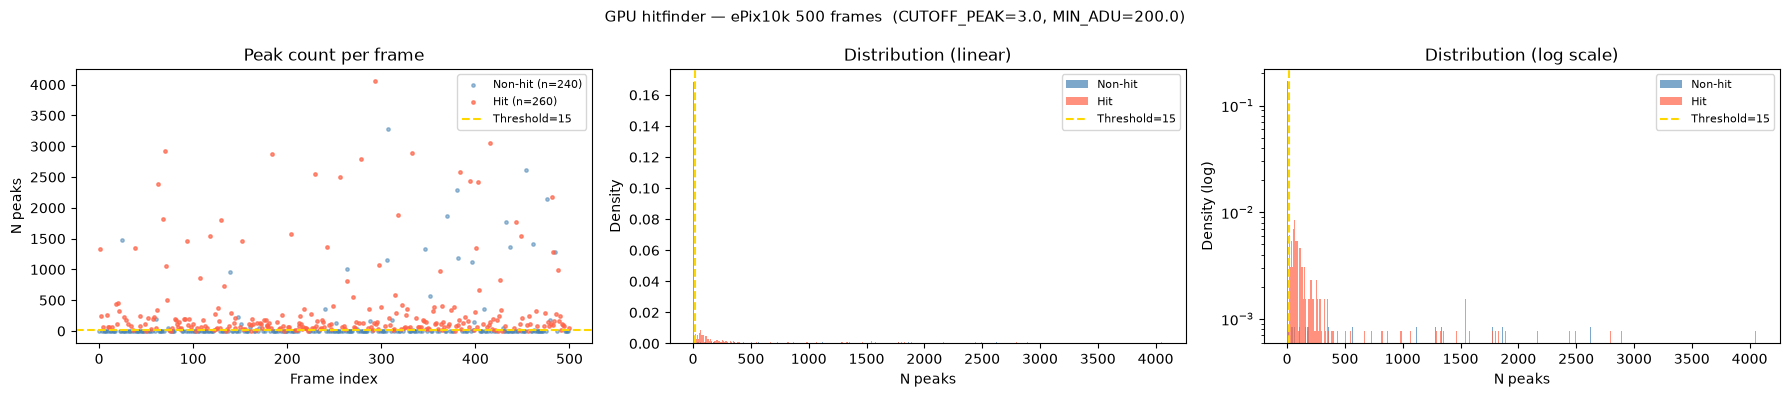

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Scatter: frame index vs n_peaks ──────────────────────────────────────────
ax = axes[0]
ax.scatter(frame_indices[nonhit_mask], n_peaks_arr[nonhit_mask],
           s=6, color="steelblue", alpha=0.5, label=f"Non-hit (n={n_nonhits})")
ax.scatter(frame_indices[hit_mask], n_peaks_arr[hit_mask],
           s=6, color="tomato", alpha=0.7, label=f"Hit (n={n_hits})")
ax.axhline(HIT_THRESHOLD, ls="--", color="gold", lw=1.5,
           label=f"Threshold={HIT_THRESHOLD}")
ax.set_xlabel("Frame index")
ax.set_ylabel("N peaks")
ax.set_title("Peak count per frame")
ax.legend(fontsize=8)

# ── Histogram (linear) ───────────────────────────────────────────────────────
bins = np.arange(0, n_peaks_arr.max() + 10, 5)
ax = axes[1]
ax.hist(n_peaks_arr[nonhit_mask], bins=bins, color="steelblue", alpha=0.7,
        density=True, label=f"Non-hit")
ax.hist(n_peaks_arr[hit_mask],    bins=bins, color="tomato",    alpha=0.7,
        density=True, label=f"Hit")
ax.axvline(HIT_THRESHOLD, ls="--", color="gold", lw=1.5,
           label=f"Threshold={HIT_THRESHOLD}")
ax.set_xlabel("N peaks")
ax.set_ylabel("Density")
ax.set_title("Distribution (linear)")
ax.legend(fontsize=8)

# ── Histogram (log) ──────────────────────────────────────────────────────────
ax = axes[2]
ax.hist(n_peaks_arr[nonhit_mask], bins=bins, color="steelblue", alpha=0.7,
        density=True, label=f"Non-hit")
ax.hist(n_peaks_arr[hit_mask],    bins=bins, color="tomato",    alpha=0.7,
        density=True, label=f"Hit")
ax.axvline(HIT_THRESHOLD, ls="--", color="gold", lw=1.5,
           label=f"Threshold={HIT_THRESHOLD}")
ax.set_xlabel("N peaks")
ax.set_ylabel("Density (log)")
ax.set_title("Distribution (log scale)")
ax.set_yscale("log")
ax.legend(fontsize=8)

fig.suptitle(f"GPU hitfinder — ePix10k {N} frames  "
             f"(CUTOFF_PEAK={GPU_CUTOFF_PEAK}, MIN_ADU={MIN_ADU})", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Timing and confusion matrix

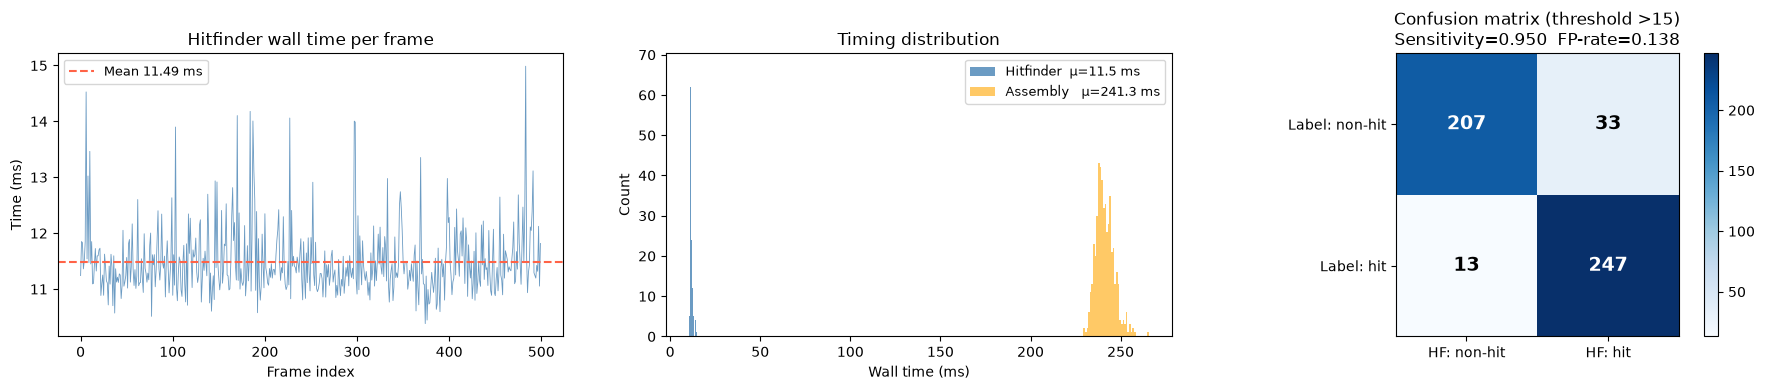

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Per-frame hitfinder time ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(frame_indices, time_hf_ms, lw=0.6, color="steelblue", alpha=0.8)
ax.axhline(time_hf_ms.mean(), ls="--", color="tomato", lw=1.5,
           label=f"Mean {time_hf_ms.mean():.2f} ms")
ax.set_xlabel("Frame index")
ax.set_ylabel("Time (ms)")
ax.set_title("Hitfinder wall time per frame")
ax.legend(fontsize=9)

# ── Timing histogram ─────────────────────────────────────────────────────────
ax = axes[1]
ax.hist(time_hf_ms,  bins=40, color="steelblue", alpha=0.8,
        label=f"Hitfinder  μ={time_hf_ms.mean():.1f} ms")
ax.hist(time_asm_ms, bins=40, color="orange",    alpha=0.6,
        label=f"Assembly   μ={time_asm_ms.mean():.1f} ms")
ax.set_xlabel("Wall time (ms)")
ax.set_ylabel("Count")
ax.set_title("Timing distribution")
ax.legend(fontsize=9)

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = np.array([[tn, fp], [fn, tp]])
ax = axes[2]
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["HF: non-hit", "HF: hit"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Label: non-hit", "Label: hit"])
ax.set_title(f"Confusion matrix (threshold >{HIT_THRESHOLD})\n"
             f"Sensitivity={sensitivity:.3f}  FP-rate={fp_rate:.3f}")

plt.tight_layout()
plt.show()

## 6. Interactive frame viewer

Use the **◀ / ▶** buttons to step one frame, or **▶ Play** to auto-advance.  
The slider jumps to any frame directly.  
Peak arrays come from the scan — no hitfinder re-run on each step.

In [64]:
def load_and_assemble(frame_idx: int) -> np.ndarray:
    with h5py.File(EPIX_CXI_PATH, "r") as f:
        raw = f["entry_1/data_1/data"][frame_idx].astype(np.float32)
    return assemble_only(raw, pads, "ePix10k 2.2M", assembler=assembler)


# ── Widgets ──────────────────────────────────────────────────────────────────
play_btn = widgets.Play(
    value=0, min=0, max=N - 1, step=1,
    interval=600,          # ms between auto-advance steps
    description="▶ Play",
    layout=widgets.Layout(width="120px"),
)
slider = widgets.IntSlider(
    value=0, min=0, max=N - 1, step=1,
    description="Frame",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)
back_btn = widgets.Button(
    description="◀ Back",
    layout=widgets.Layout(width="90px"),
)
fwd_btn = widgets.Button(
    description="Forward ▶",
    layout=widgets.Layout(width="100px"),
)
info_label = widgets.Label(value="")
out = widgets.Output()

# Link play button and slider so they stay in sync.
widgets.jslink((play_btn, "value"), (slider, "value"))


def render(frame_idx: int) -> None:
    """Assemble frame and draw peak overlay."""
    asm   = load_and_assemble(frame_idx)
    peaks = all_peaks[frame_idx]
    lbl   = int(labels[frame_idx])
    n_pk  = n_peaks_arr[frame_idx]
    hf_call = "HIT" if n_pk > HIT_THRESHOLD else "NON-HIT"
    correct = (hf_call == "HIT") == (lbl == 1)

    color = "tomato" if lbl == 1 else "steelblue"
    edge  = "limegreen" if correct else "orange"

    info_label.value = (
        f"Frame {frame_idx}  |  Label: {'HIT' if lbl else 'NON-HIT'}  |  "
        f"HF call: {hf_call}  |  N peaks: {n_pk}  |  "
        f"HF time: {time_hf_ms[frame_idx]:.1f} ms  |  "
        f"{'✓ correct' if correct else '✗ wrong'}"
    )

    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 7))
        vmin, vmax = np.percentile(asm, [1, 99.5])
        ax.imshow(asm, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper")

        if len(peaks) > 0:
            ax.scatter(peaks[:, 0], peaks[:, 1],
                       s=50, facecolors="none", edgecolors=color,
                       linewidths=1.5, label=f"{n_pk} peaks")
            ax.legend(loc="upper right", fontsize=9)
        else:
            ax.text(0.5, 0.5, "0 peaks", transform=ax.transAxes,
                    ha="center", va="center", color="white", fontsize=14)

        # Border colour: green = correct call, orange = wrong call.
        for spine in ax.spines.values():
            spine.set_edgecolor(edge)
            spine.set_linewidth(4)

        ax.set_title(
            f"Frame {frame_idx}  |  Label: {'HIT' if lbl else 'NON-HIT'}  |  "
            f"HF: {hf_call}  ({n_pk} peaks)\n"
            f"CUTOFF_PEAK={GPU_CUTOFF_PEAK}  MIN_ADU={MIN_ADU}",
            fontsize=10,
        )
        ax.set_xlabel("x (px)")
        ax.set_ylabel("y (px)")
        plt.tight_layout()
        plt.show()


def on_slider_change(change):
    render(change["new"])


def on_back(_):
    slider.value = max(0, slider.value - 1)


def on_fwd(_):
    slider.value = min(N - 1, slider.value + 1)


slider.observe(on_slider_change, names="value")
back_btn.on_click(on_back)
fwd_btn.on_click(on_fwd)

controls = widgets.HBox([back_btn, play_btn, fwd_btn, slider])
display(widgets.VBox([controls, info_label, out]))

render(0)  # show first frame on load